In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import pandas as pd
import pickle
import healsparse
import healpy as hp
import sys
import treecorr
import h5py

plt.rcParams.update({
    'font.family':'serif',
    'font.size':12.0,
    'axes.labelsize': 'x-large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large',
    'axes.titlesize':'x-large',
    'legend.fontsize': 'large',
    'xtick.direction':'in',
    'ytick.direction':'in',
    'lines.linewidth':2,
    'patch.linewidth':2, # for hist
    'lines.color':'black',
    'mathtext.fontset' : 'stix',
    'figure.titlesize': 'xx-large',
    'figure.facecolor':  (1.0, 1.0, 1.0, 1.0),
    'axes.facecolor':    (1.0, 1.0, 1.0, 1.0), 
    'savefig.facecolor': (1.0, 1.0, 1.0, 1.0)})

colors = ['dodgerblue', 'darkgreen', 'darkorange', 'darkred', 'violet', 'slateblue']

In [2]:
props_mdet = ['ra', 'dec', 'gauss_g_1', 'gauss_g_2', 'pgauss_band_flux_g', 'pgauss_band_flux_i', 'pgauss_band_flux_r', 'pgauss_band_flux_z']

props_maglim = ['ra', 'dec', 'Z_MEAN', 'Z_MC',
                'BDF_MAG_CORRDERED_G', 'BDF_MAG_CORRDERED_I', 'BDF_MAG_CORRDERED_R', 'BDF_MAG_CORRDERED_Y', 'BDF_MAG_CORRDERED_Z'] 
zs_maglim = [0.2, 0.4, 0.55, 0.7, 0.85, 0.95, 1.05]

props_ran = ['ra', 'dec', 'z'] #weight?

zbins_s = 4
zbins_l = 6

In [3]:
dir_des = '/global/cfs/cdirs/des/'

mdet_cat = dir_des + '/y6-shear-catalogs/Y6A2_METADETECT_V5a/metadetect_desdmv5a_cutsv5.h5'
sompz_cat = dir_des + '/acampos/sompz_output/y6_data_preliminary/sompz_y6_data_preliminary.hdf5'
weights_mdet_cat = '/pscratch/sd/m/myamamot/des-y6-analysis/y6_measurement/v5b/inverse_variance_weight_v5b_s2n_10-1000_Tratio_0.5-5.pickle'

maglim_cat = dir_des + 'nweaverd/des_y6/maglim_plusplus/y6maglim_VIPERS_a18_b4_v2.0_pzcols_wisecols.fits'
ran_cat = dir_des + 'jelvinpo/y6_randoms/y6maglim_randoms_rr40.0_y6_maglim_jointmask_fiducial.fits'

shear_map = dir_des + 'y6-shear-catalogs/y6-combined-hleda-gaiafull-des-stars-hsmap16384-nomdet-v3.fits'
lss_map = dir_des + 'monroy/Y6A2/maglim/sp_outliers_analysis/maglim_mask/jointmasks_fiducial/Y6LSSBAO_V2_MASK_WITHDEPTH_up_to_22.2_jointmask_3.5iqr_sps_0.01percent_sb_mean_0.5max_val_neb_mean_gcs_bit64_joint_vl05_vl10_vlim_zmax_gaia512_shear_flim0.8_bad_regions_gold20.fits.gz'

dir_elisa = dir_des + 'elisa/ggl_y6_bfd/'

In [33]:
def convert_to_pix_coord(ra, dec, nside=1024,nest=False):
    """
    Converts RA,DEC to hpix coordinates
    """
    theta = (90.0 - dec) * np.pi / 180.
    phi = ra * np.pi / 180.
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    return pix

def flux2mag(flux, zero_pt=30):
    return zero_pt - 2.5 * np.log10(flux) 


def get_shear_weights(weights_file):
    
        def _assign_loggrid(x, y, xmin, xmax, xsteps, ymin, ymax, ysteps):
            from math import log10
            # return x and y indices of data (x,y) on a log-spaced grid that runs from [xy]min to [xy]max in [xy]steps

            logstepx = log10(xmax/xmin)/xsteps
            logstepy = log10(ymax/ymin)/ysteps

            indexx = (np.log10(x/xmin)/logstepx).astype(int)
            indexy = (np.log10(y/ymin)/logstepy).astype(int)

            indexx = np.maximum(indexx,0)
            indexx = np.minimum(indexx, xsteps-1)
            indexy = np.maximum(indexy,0)
            indexy = np.minimum(indexy, ysteps-1)

            return indexx,indexy

        def _find_shear_weight(wgt_dict, snmin, snmax, sizemin, sizemax, steps):

            if wgt_dict is None:
                weights = np.ones(len(d))
                return weights
            
            with h5py.File(mdet_cat, 'r') as cat:
                d = cat['mdet/noshear']

                shear_wgt = wgt_dict['weight']
                from scipy.ndimage import gaussian_filter
                smooth_response = gaussian_filter(wgt_dict['response'], sigma=2.0)
                shear_wgt = (smooth_response/wgt_dict['meanes'])**2
                indexx, indexy = _assign_loggrid(d['gauss_s2n'][:], d['gauss_T_ratio'][:], snmin, snmax, steps, sizemin, sizemax, steps)
                weights = np.array([shear_wgt[x, y] for x, y in zip(indexx, indexy)])

            return weights
  
        # pickle file that defines w(S/N, size)
        with open(weights_file, 'rb') as handle:
            wgt_dict = pickle.load(handle)
        shear_wgt = _find_shear_weight(wgt_dict, 10, 1000, 0.5, 5.0, 20)      
        
        return shear_wgt

In [5]:
def create_mask(path_cat):
    
    with fits.open(path_cat) as cat:
        
        ra = np.array(cat[1].data['ra'])
        dec = np.array(cat[1].data['dec'])
        pix = convert_to_pix_coord(ra, dec, nside=4096)
        
        print('full cat before masking:', len(ra))
        
        hmap = healsparse.HealSparseMap.read(shear_map)
        mask_shear = hmap.get_values_pos(ra, dec, valid_mask=True)
        
        with fits.open(lss_map) as lss_map_:
            pix_lss= lss_map_[1].data['HPIX_4096']
            mask_lss = np.in1d(pix, pix_lss)
        
        mask_joint = mask_shear & mask_lss 
        
    print('mask created')

    return mask_joint

def create_mask_h5(path_cat):
    
    with h5py.File(path_cat, 'r') as cat:
        
        ra = np.array(cat['mdet/noshear/ra'])
        dec = np.array(cat['mdet/noshear/dec'])
        pix = convert_to_pix_coord(ra, dec, nside=4096)
        
        print('full cat before masking:', len(ra))
        
        hmap = healsparse.HealSparseMap.read(shear_map)
        mask_shear = hmap.get_values_pos(ra, dec, valid_mask=True)
        
        with fits.open(lss_map) as lss_map_:
            pix_lss= lss_map_[1].data['HPIX_4096']
            mask_lss = np.in1d(pix, pix_lss)
        
        mask_joint = mask_shear & mask_lss 
        
    print('mask created')

    return mask_joint

def read_cat(path_cat, props, mask):
    
    with fits.open(path_cat) as cat:
        
        print('props:')
        data = pd.DataFrame()
        for p in props:
            print('  ', p)
            data[p] = np.array(cat[1].data[p])[mask]
            
    print('full cat:', len(data[props[0]]))
            
    return data

def read_cat_h5(path_cat, props, mask):
    
    with h5py.File(path_cat, 'r') as cat:
        
        print('props:')
        data = pd.DataFrame()
        for p in props:
            print('  ', p)
            data[p] = np.array(cat['mdet/noshear/'+p])[mask]
            
        with h5py.File(sompz_cat, 'r') as cat2:
            data['tomo_bin'] = np.array(cat2['catalog/sompz/noshear/bhat'])[mask]
            
    print('full cat:', len(data[props[0]]))
            
    return data

def select_tomo_bin(data, props, zbin):

    mask_z = (data['tomo_bin'] == zbin)

    bin_i = pd.DataFrame()
    for p in props:
        bin_i[p] = data[p][mask_z]
        
    print(f'bin {zbin}:', len(bin_i[props[0]]))
    
    return bin_i

def plot_prop(cat_bins, cat_type, prop, bins, xlims=False):
    
    fig = plt.figure(figsize=(7, 5))
    plt.title(cat_type)
    
    if cat_type=='mdet': zbins=zbins_s
    elif cat_type=='maglim': zbins=zbins_l
    
    for i in range(zbins):
        plt.hist(cat_bins[i][prop], histtype='step', color=colors[i], bins=bins, density=True, label=f'bin {i+1}')
        
    if xlims: plt.xlim(xlims[0], xlims[1])  
    plt.xlabel(prop)
    plt.ylabel('n')
    plt.legend()
    plt.tight_layout()
    fig.patch.set_alpha(1.0)
    plt.show()
    
    return

In [6]:
conf = {'nbins': 20,
        'min_sep': 2.5/60.,
        'max_sep': 250./60.,
        'sep_units': 'deg',
        'bin_slop': 0.0
       }

def setup_ggl(bin_s, bin_l):

    cat_s = treecorr.Catalog(ra=bin_s['ra'], dec=bin_s['dec'], w=bin_s['w'], ra_units='deg', dec_units='deg', 
                             g1=bin_s['e1'], g2=bin_s['e2'],
                             npatch=200)
    
    cat_l = treecorr.Catalog(ra=bin_l['ra'], dec=bin_l['dec'], ra_units='deg', dec_units='deg',
                             patch_centers=cat_s.patch_centers)
    
    return cat_s, cat_l

def run_ggl_ng(cat_s, cat_l):
    
    ng = treecorr.NGCorrelation(conf, var_method='jackknife')
    ng.process(cat_l, cat_s)
    
    theta = ng.rnom*60
    gammat = ng.xi
    gammat_err = np.sqrt(ng.estimate_cov('jackknife').diagonal())
    gammax = ng.xi_im
    
    return theta, gammat, gammat_err, gammax

def write_data(data, file_path):
    with open(file_path, 'a') as f:
        f.writelines(f"{line}\n" for line in data)
    
    
########### TO DO: compute it in run_ggl_ng
def run_ggl_rg(cat_s, cat_ran):
    
    rg = treecorr.NGCorrelation(conf)#, var_met='jackknife')
    rg.process(cat_ran, cat_s)
    
    gammat_ran = rg.xi

    return gammat_ran

In [7]:
def read_data(file_path):
    data = []
    with open(file_path, 'r') as file:
        for line in file:
            data.append(float(line.strip()))
    return np.array(data)
    
def plot_gammat(theta, gammat, gammat_err):
    
    fig = plt.figure(figsize=(14, 10))
    plt.suptitle('Galaxy-galaxy lensing Metadetect - MagLim++\n')
    
    for l in range(zbins_l):
        for s in range(zbins_s):
            
            response = np.loadtxt('/global/cfs/cdirs/des/giannini/ggl/v5a_sompz/Response_bin'+str(s)+'.txt')[0]
        
            plt.subplot(2, 3, l+1)
            plt.errorbar(theta, gammat[l][s]/response, gammat_err[l][s], ls='', marker='.', color=colors[s], label=f'source bin {s+1}')

        plt.title(f'lens bin {l+1}')
        plt.yscale('log')
        plt.xscale('log')
        if l in (3, 4, 5): plt.xlabel(r'$\theta$ [arcmin]')
        if l in (0, 3): plt.ylabel(r'$\gamma_t (\theta)$')
        if l==0: plt.legend()
        plt.yticks([])

    plt.tight_layout()
    fig.patch.set_alpha(1.0)
    plt.savefig('gammat_mdet.png', dpi=150, bbox_inches='tight')
    plt.show()

### Select Metadetect data

In [16]:
mask_mdet = create_mask_h5(mdet_cat)
mdet = read_cat_h5(mdet_cat, props_mdet, mask_mdet)

full cat before masking: 150093691
mask created
props:
   ra
   dec
   gauss_g_1
   gauss_g_2
   pgauss_band_flux_g
   pgauss_band_flux_i
   pgauss_band_flux_r
   pgauss_band_flux_z
full cat: 135664742


In [19]:
w = get_shear_weights(weights_mdet_cat)
mdet['w'] = w[mask_mdet]

In [21]:
props_mdet = ['ra', 'dec', 'gauss_g_1', 'gauss_g_2', 'w', 'pgauss_band_flux_g', 'pgauss_band_flux_i', 'pgauss_band_flux_r', 'pgauss_band_flux_z']

mdet_bins = [pd.DataFrame() for i in range(zbins_s)]
for i in range(zbins_s):
    mdet_bins[i]=select_tomo_bin(mdet, props_mdet, i)

assert len(mdet['ra']) == sum(len(mdet_bins[i]['ra']) for i in range(zbins_s))

bin 0: 34029978
bin 1: 33420237
bin 2: 34081767
bin 3: 34132760


In [22]:
for i in range(zbins_s):
    with open(dir_elisa+f'mdet_selected_zbin_{i}.pkl', 'wb') as file:
        pickle.dump(mdet_bins[i], file)
    print('bin', str(i), 'saved to file')

bin 0 saved to file
bin 1 saved to file
bin 2 saved to file
bin 3 saved to file


### Select MagLim data

In [10]:
mask_maglim = create_mask(maglim_cat)
maglim = read_cat(maglim_cat, props_maglim, mask_maglim)

maglim['tomo_bin'] = -np.ones(len(maglim['ra']), dtype=int)
for i in range(0,6):
    mask_z = (maglim['Z_MEAN'] >= zs_maglim[i]) & (maglim['Z_MEAN'] < zs_maglim[i+1])
    maglim['tomo_bin'].loc[mask_z] = i

full cat before masking: 10495787
mask created
props:
   ra
   dec
   Z_MEAN
   Z_MC
   BDF_MAG_CORRDERED_G
   BDF_MAG_CORRDERED_I
   BDF_MAG_CORRDERED_R
   BDF_MAG_CORRDERED_Y
   BDF_MAG_CORRDERED_Z
full cat: 9290429


/tmp/ipykernel_1343857/3306122372.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  maglim['tomo_bin'].loc[mask_z] = i


In [11]:
maglim_bins = [pd.DataFrame() for i in range(zbins_l)]
for i in range(zbins_l):
    maglim_bins[i]=select_tomo_bin(maglim, np.append(props_maglim, 'tomo_bin'), i)
    
assert len(maglim['ra']) == sum(len(maglim_bins[i]['ra']) for i in range(zbins_l))

bin 0: 1850096
bin 1: 1384948
bin 2: 1426696
bin 3: 1830710
bin 4: 1398087
bin 5: 1399892


In [16]:
with open(dir_elisa+'maglim_selected.pkl', 'wb') as file:
    pickle.dump(maglim_bins, file)
print('saved to file')

### Select randoms data

In [10]:
mask_ran = create_mask(ran_cat)
randoms = read_cat(ran_cat, props_ran, mask_ran)

randoms['tomo_bin'] = -np.ones(len(randoms['ra']), dtype=int)
for i in range(0,6):
    mask_z = (randoms['z'] >= zs_maglim[i]) & (randoms['z'] < zs_maglim[i+1])
    randoms['tomo_bin'].loc[mask_z] = i

full cat before masking: 417027820
mask created
props:
   ra
   dec
   z
full cat: 404988638


/tmp/ipykernel_1522543/2412903240.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  randoms['tomo_bin'].loc[mask_z] = i


In [11]:
randoms_bins = [pd.DataFrame() for i in range(zbins_l)]
for i in range(zbins_l):
    randoms_bins[i]=select_tomo_bin(randoms, np.append(props_ran, 'tomo_bin'), i)
    
assert len(randoms['ra']) == sum(len(randoms_bins[i]['ra']) for i in range(zbins_l))

bin 0: 82112376
bin 1: 60267796
bin 2: 62231215
bin 3: 79332323
bin 4: 60603655
bin 5: 60441273


In [12]:
with open(dir_elisa+'randoms_selected.pkl', 'wb') as file:
    pickle.dump(randoms_bins, file)
print('saved to file')

saved to file


### Load selected data

In [8]:
mdet_bins = [pd.DataFrame() for i in range(zbins_s+1)]
for i in range(zbins_s):
    with open(dir_elisa+'mdet_selected_zbin_'+str(i)+'.pkl', 'rb') as file:
        mdet_bins[i] = pickle.load(file)
    
maglim_bins = [pd.DataFrame() for i in range(zbins_l)]
with open(dir_elisa+'maglim_selected.pkl', 'rb') as file:
    maglim_bins = pickle.load(file)
    
randoms_bins = [pd.DataFrame() for i in range(zbins_l)]
with open(dir_elisa+'randoms_selected.pkl', 'rb') as file:
    randoms_bins = pickle.load(file)

In [9]:
for i in range(zbins_s):
    mdet_bins[i]['e1'] = mdet_bins[i]['gauss_g_1']
    mdet_bins[i]['e2'] = mdet_bins[i]['gauss_g_2']

### Run galaxy-galaxy lensing measurements

#### ng

In [10]:
for l, bin_l in enumerate(maglim_bins):
    print(f'\nmaglim bin {l+1}:', len(bin_l['ra']))
    
    for s, bin_s in enumerate(mdet_bins[:-1]):
        print(f'   mdet bin {s+1}:', len(bin_s['ra']))
        
        cat_s, cat_l = setup_ggl(bin_s, bin_l)
        theta, gammat, gammat_err, gammax = run_ggl_ng(cat_s, cat_l)
        
        write_data(gammat, dir_elisa+f'gammat_l{l}_s{s}.txt')
        write_data(gammat_err, dir_elisa+f'gammat_err_l{l}_s{s}.txt')
        write_data(gammax, dir_elisa+f'gammax_l{l}_s{s}.txt')
            
write_data(theta, dir_elisa+'theta.txt')
print('saved to file')


maglim bin 1: 1850096
   mdet bin 1: 34029978
   mdet bin 2: 33420237
   mdet bin 3: 34081767
   mdet bin 4: 34132760

maglim bin 2: 1384948
   mdet bin 1: 34029978
   mdet bin 2: 33420237
   mdet bin 4: 34132760

maglim bin 3: 1426696
   mdet bin 1: 34029978
   mdet bin 2: 33420237
   mdet bin 3: 34081767
   mdet bin 4: 34132760

maglim bin 4: 1830710
   mdet bin 1: 34029978
   mdet bin 2: 33420237
   mdet bin 3: 34081767
   mdet bin 4: 34132760

maglim bin 5: 1398087
   mdet bin 1: 34029978
   mdet bin 2: 33420237
   mdet bin 3: 34081767
   mdet bin 4: 34132760

maglim bin 6: 1399892
   mdet bin 1: 34029978
   mdet bin 2: 33420237
   mdet bin 3: 34081767
   mdet bin 4: 34132760
saved to file


#### rg

In [ ]:
########### TO DO: compute it in run_gll_ng
for r, bin_r in enumerate(randoms_bins):
    print('\nrandom bin '+str(r+1)+':', len(bin_r['ra']))
    
    for s, bin_s in enumerate(mdet_bins[:-1]):
        print('   mdet bin '+str(s+1)+':', len(bin_s['ra']))
        
        cat_s, cat_r = setup_ggl(bin_s, bin_r)
        gammat_ran = run_ggl_rg(cat_s, cat_r)
        
        write_data(gammat_ran, dir_elisa+f'gammat_ran_l{r}_s{s}.txt')
        
print('saved to file')

### Load and plot saved galaxy-galaxy lensing measurements

In [10]:
theta = read_data(dir_elisa + 'gammat/theta.txt')

gammat = [[np.ones(len(theta))*i for i in range(zbins_s)] for l in range(zbins_l)]
gammat_err = np.copy(gammat)
#gammat_ran = np.copy(gammat)
gammax = np.copy(gammat)
#gammat_tot = np.copy(gammat)

for l in range(zbins_l):
    for s in range(zbins_s):
        gammat[l][s] = read_data(dir_elisa + f'gammat_mdet/gammat_l{l}_s{s}.txt')
        gammat_err[l][s] = read_data(dir_elisa + f'gammat_mdet/gammat_err_l{l}_s{s}.txt')
        #gammat_ran[l][s] = read_data(dir_elisa + f'gammat_mdet_no_w/gammat_ran_l{l}_s{s}.txt')
        gammax[l][s] = read_data(dir_elisa + f'gammat_mdet/gammax_l{l}_s{s}.txt')
        
#gammat_tot = gammat - gammat_ran

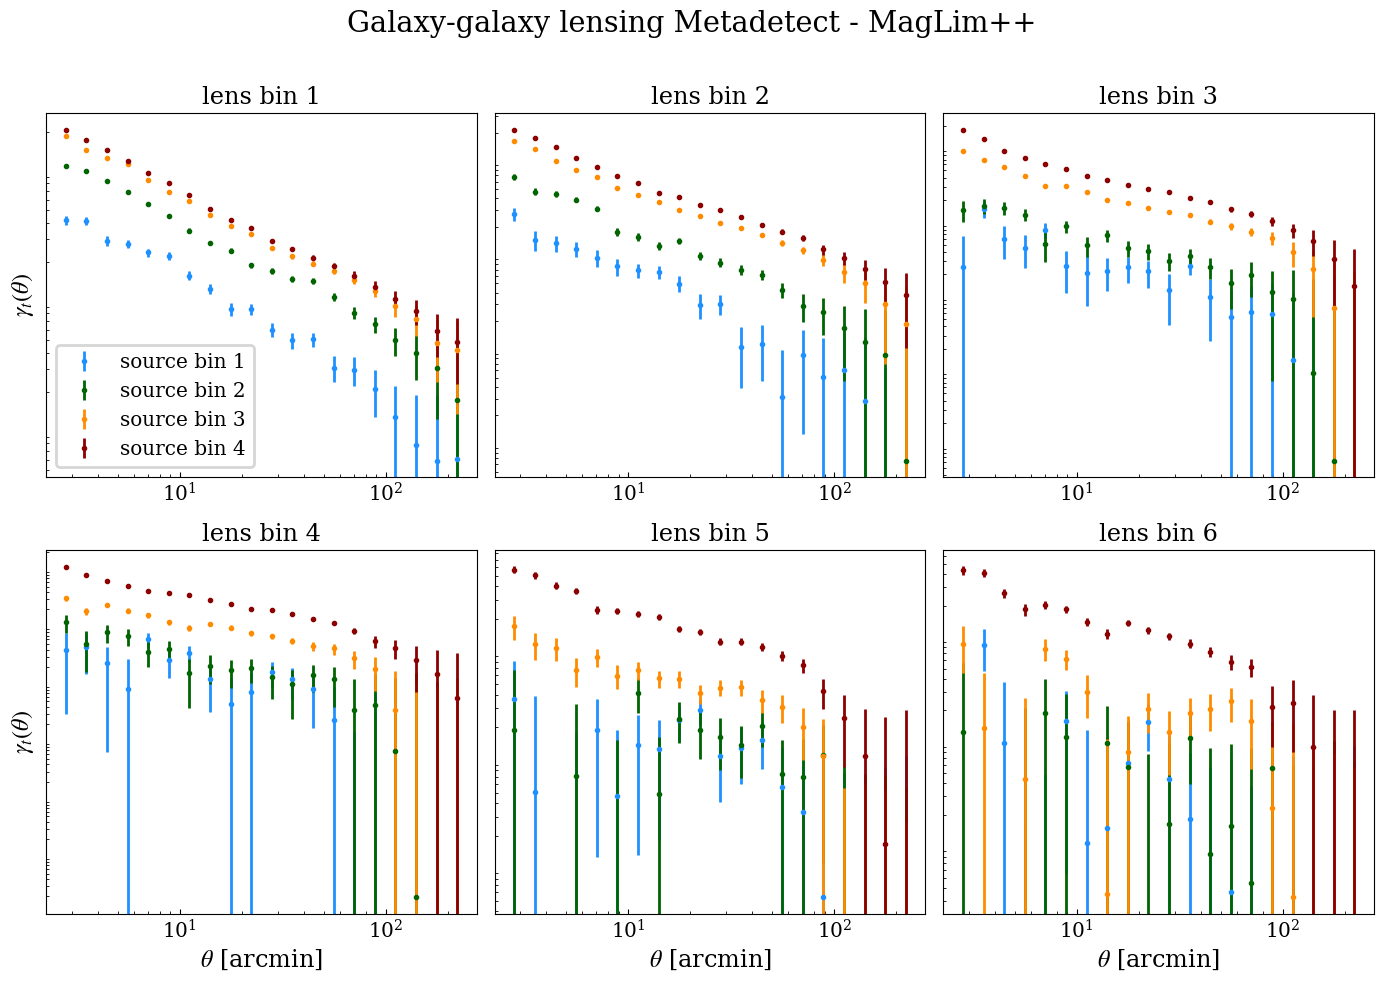

In [11]:
plot_gammat(theta, gammat, gammat_err)

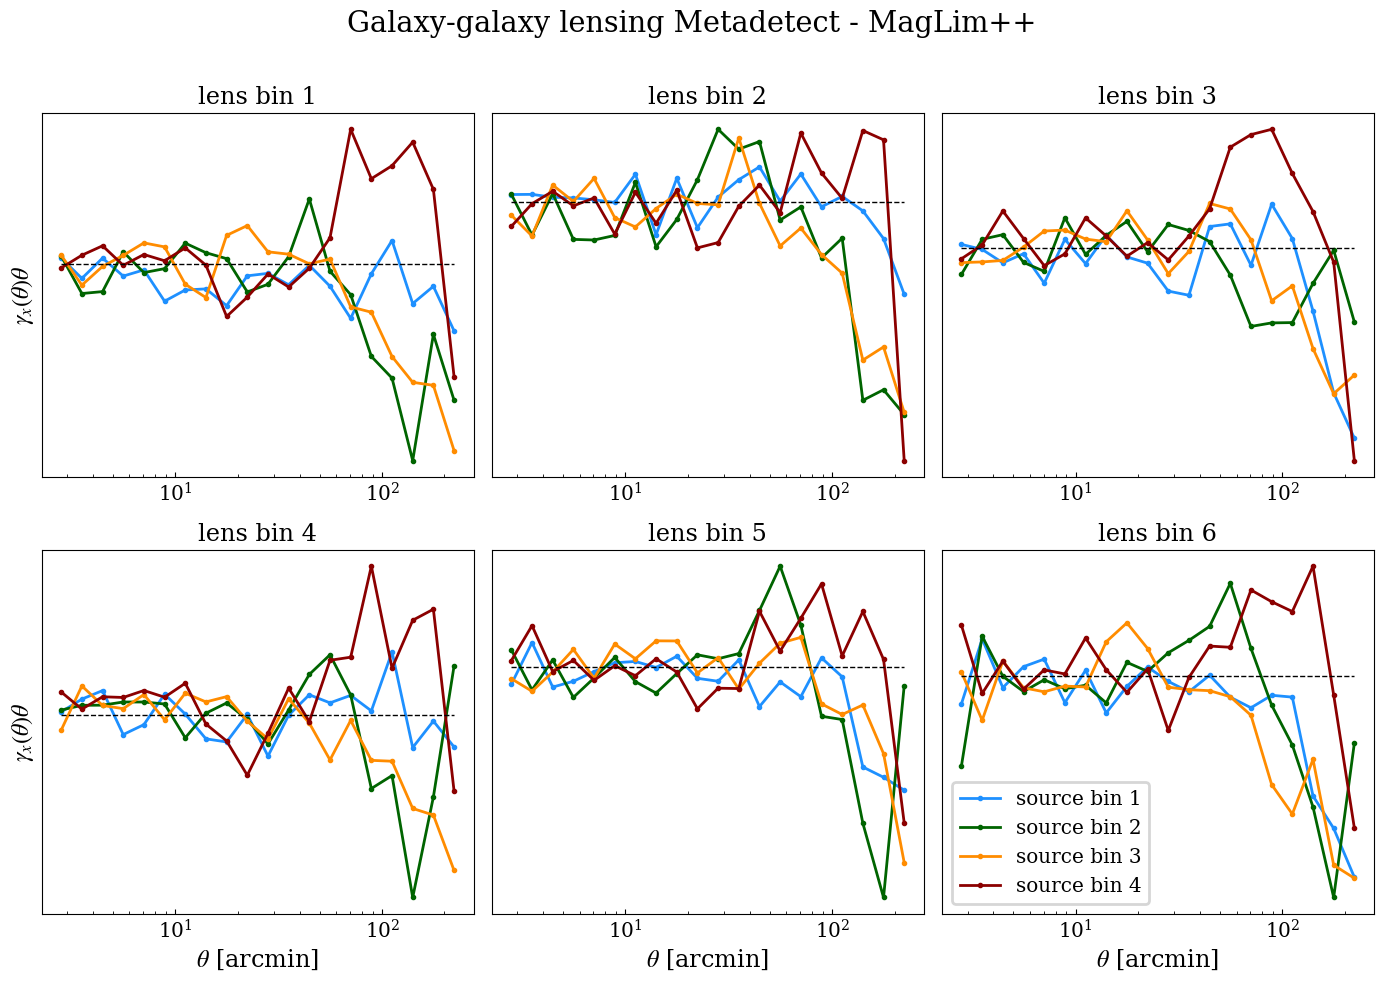

In [12]:
fig = plt.figure(figsize=(14, 10))
plt.suptitle('Galaxy-galaxy lensing Metadetect - MagLim++\n')

for l in range(zbins_l):
    for s in range(zbins_s):
        
        plt.subplot(2, 3, l+1)
        plt.plot(theta, gammax[l][s]*theta, marker='.', color=colors[s], label=f'source bin {s+1}')

    plt.title(f'lens bin {l+1}')
    plt.xscale('log')
    plt.hlines(0, min(theta), max(theta), ls='--', lw=1)
    if l in (3, 4, 5): plt.xlabel(r'$\theta$ [arcmin]')
    if l in (0, 3): plt.ylabel(r'$\gamma_x (\theta) \theta$')
    plt.yticks([])

plt.legend()
plt.tight_layout()
fig.patch.set_alpha(1.0)
plt.savefig('gammax_mdet.png', dpi=150, bbox_inches='tight')
plt.show()

## Some extra plots

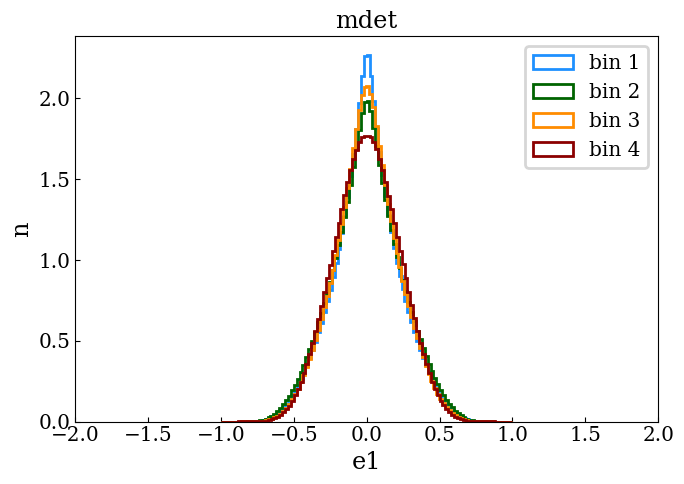

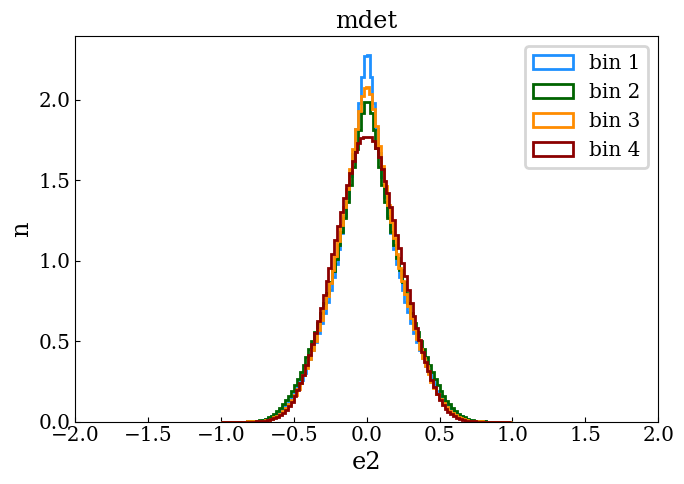

In [14]:
plot_prop(mdet_bins, 'mdet', 'e1', bins=100, xlims=[-2,2])
plot_prop(mdet_bins, 'mdet', 'e2', bins=100, xlims=[-2,2])

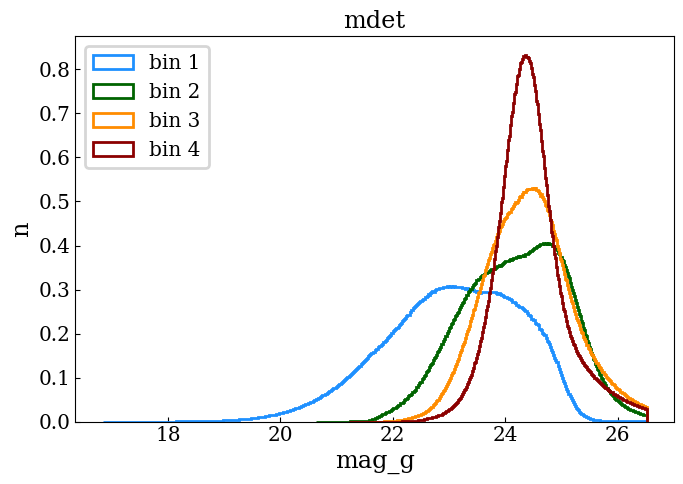

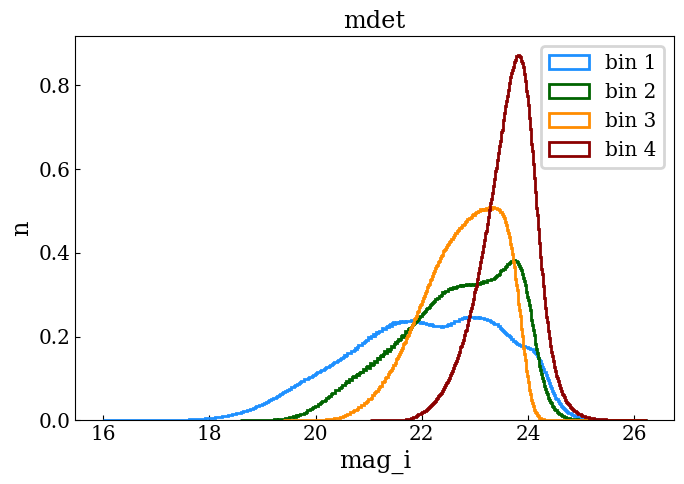

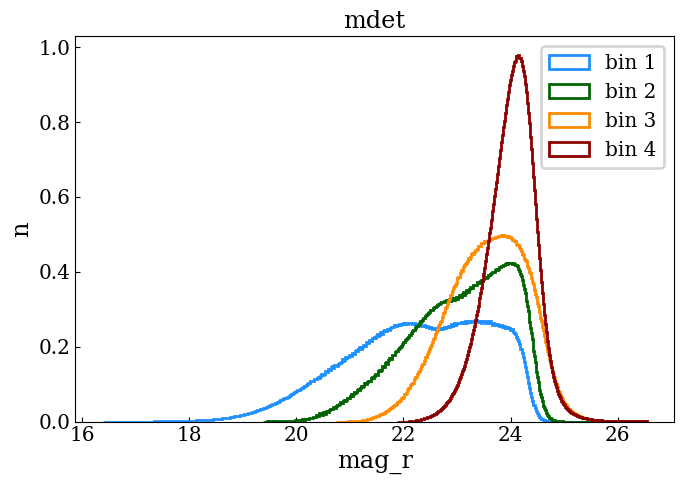

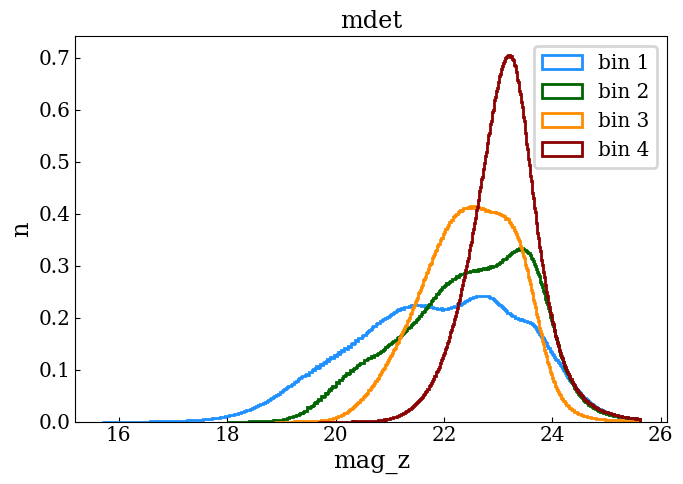

In [38]:
for i in range(zbins_s):
    mdet_bins[i]['mag_g'] = flux2mag(mdet_bins[i]['pgauss_band_flux_g'])
    mdet_bins[i]['mag_i'] = flux2mag(mdet_bins[i]['pgauss_band_flux_i'])
    mdet_bins[i]['mag_r'] = flux2mag(mdet_bins[i]['pgauss_band_flux_r'])
    mdet_bins[i]['mag_z'] = flux2mag(mdet_bins[i]['pgauss_band_flux_z'])
    
plot_prop(mdet_bins, 'mdet', 'mag_g', bins=500)
plot_prop(mdet_bins, 'mdet', 'mag_i', bins=500)
plot_prop(mdet_bins, 'mdet', 'mag_r', bins=500)
plot_prop(mdet_bins, 'mdet', 'mag_z', bins=500)

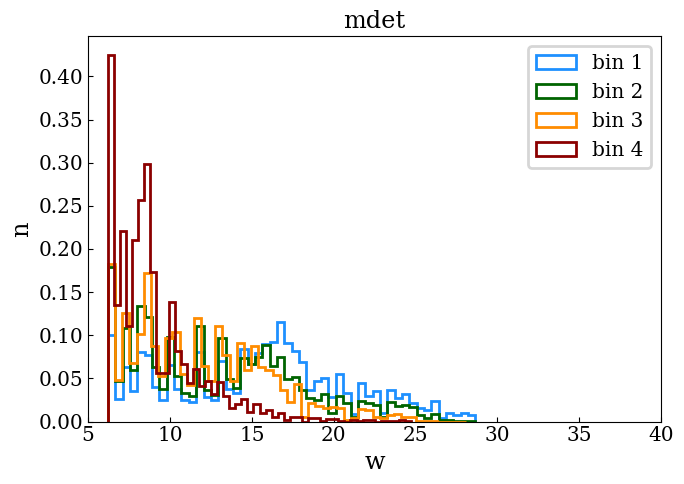

In [30]:
plot_prop(mdet_bins, 'mdet', 'w', bins=50, xlims=[5,40])

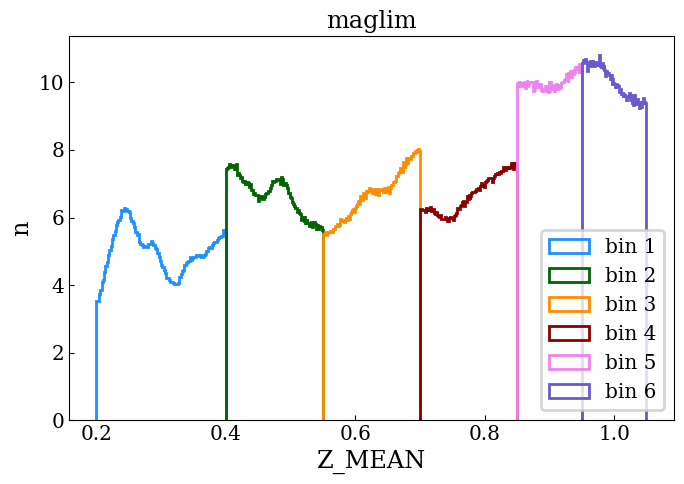

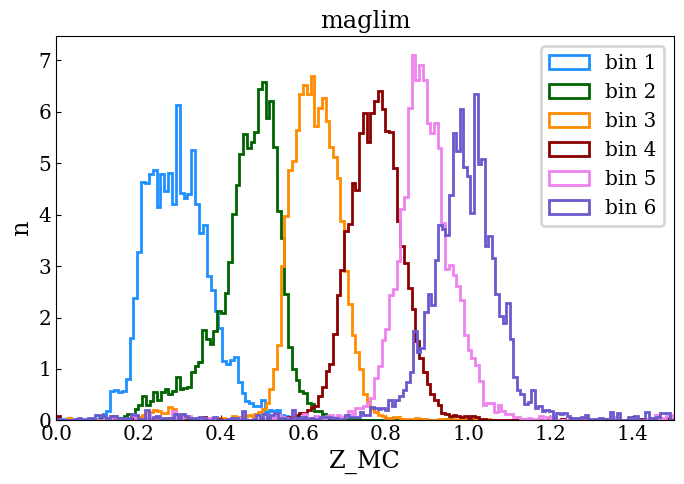

In [31]:
plot_prop(maglim_bins, 'maglim', 'Z_MEAN', bins=100)
plot_prop(maglim_bins, 'maglim', 'Z_MC', bins=500, xlims=[0,1.5])

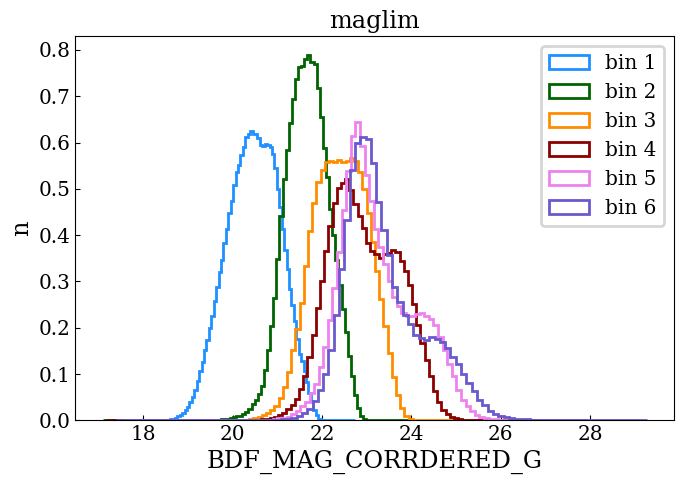

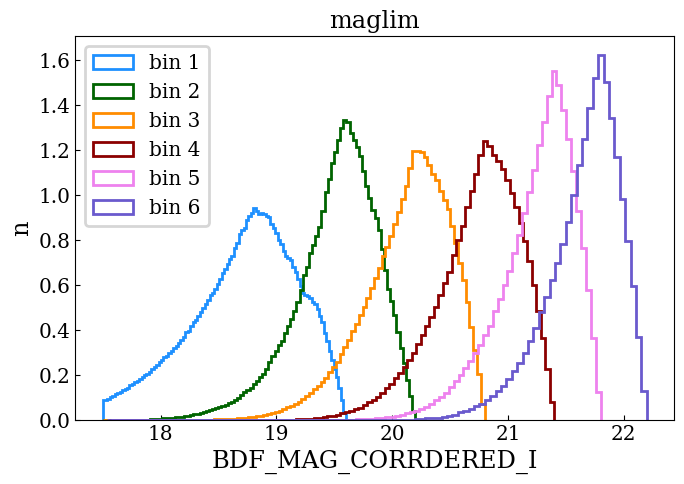

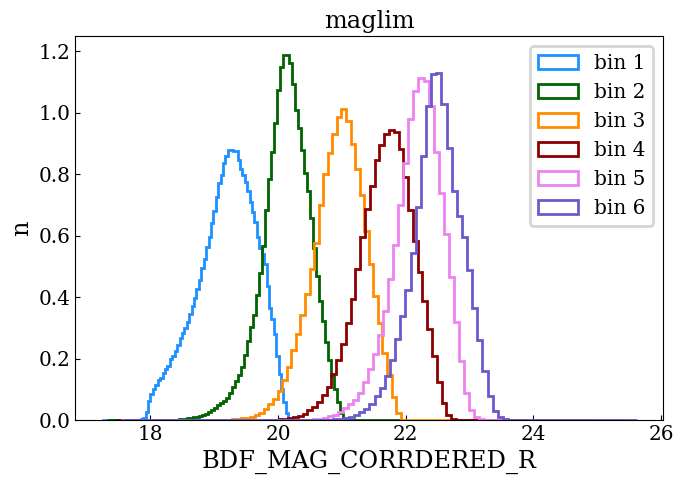

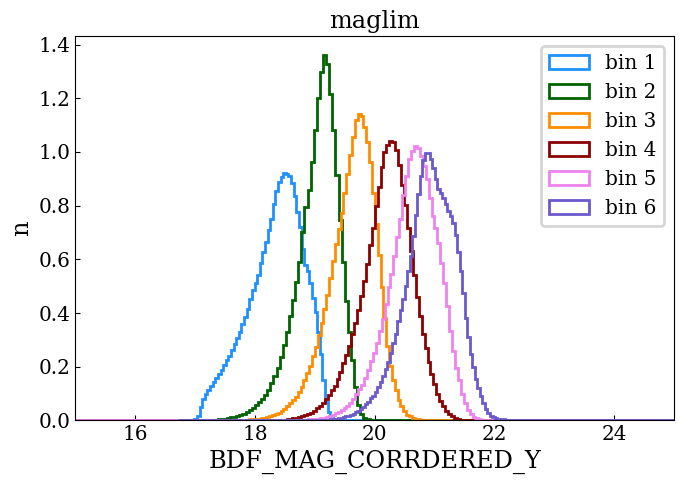

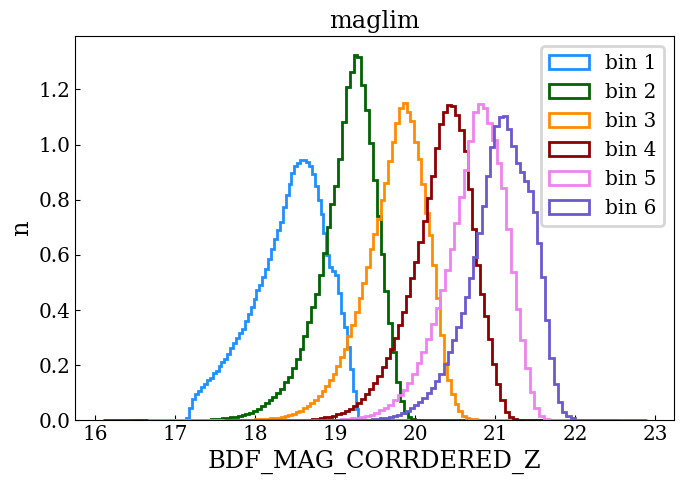

In [32]:
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_G', bins=100)
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_I', bins=100)
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_R', bins=100)
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_Y', bins=500, xlims=[15,25])
plot_prop(maglim_bins, 'maglim', 'BDF_MAG_CORRDERED_Z', bins=100)

## Compare with Giulia's catalogs

In [23]:
dir_giulia =  '/global/cfs/cdirs/des/giannini/ggl/'
       
print('Metadetect')
for i in range(zbins_s):
    with fits.open(dir_giulia+f'v5a_sompz_jointmask/metadetect_bin{i}.fits') as cat:   
        print(f'bin {i}:', len(cat[1].data))
        
print('\nMagLim++')
for i in range(zbins_l):
    with fits.open(dir_giulia+f'v5a_sompz_jointmask/maglim++_bin{i}.fits') as cat:   
        print(f'bin {i}:', len(cat[1].data))

Metadetect
bin 0: 34029978
bin 1: 33420237
bin 2: 34081767
bin 3: 34132760

MagLim++
bin 0: 1850096
bin 1: 1384948
bin 2: 1426696
bin 3: 1830710
bin 4: 1398087
bin 5: 1399892


**--> Same as mine**